Columns in CSV: ['Wall time', 'Step', 'Value']
Shape: (234, 3)
      Wall time  Step          Value
0  1.750070e+09     0  161425.937500
1  1.750070e+09     1  144224.703125
2  1.750070e+09     2   25178.248047
3  1.750070e+09     3   11540.991211
4  1.750070e+09     4   15220.788086


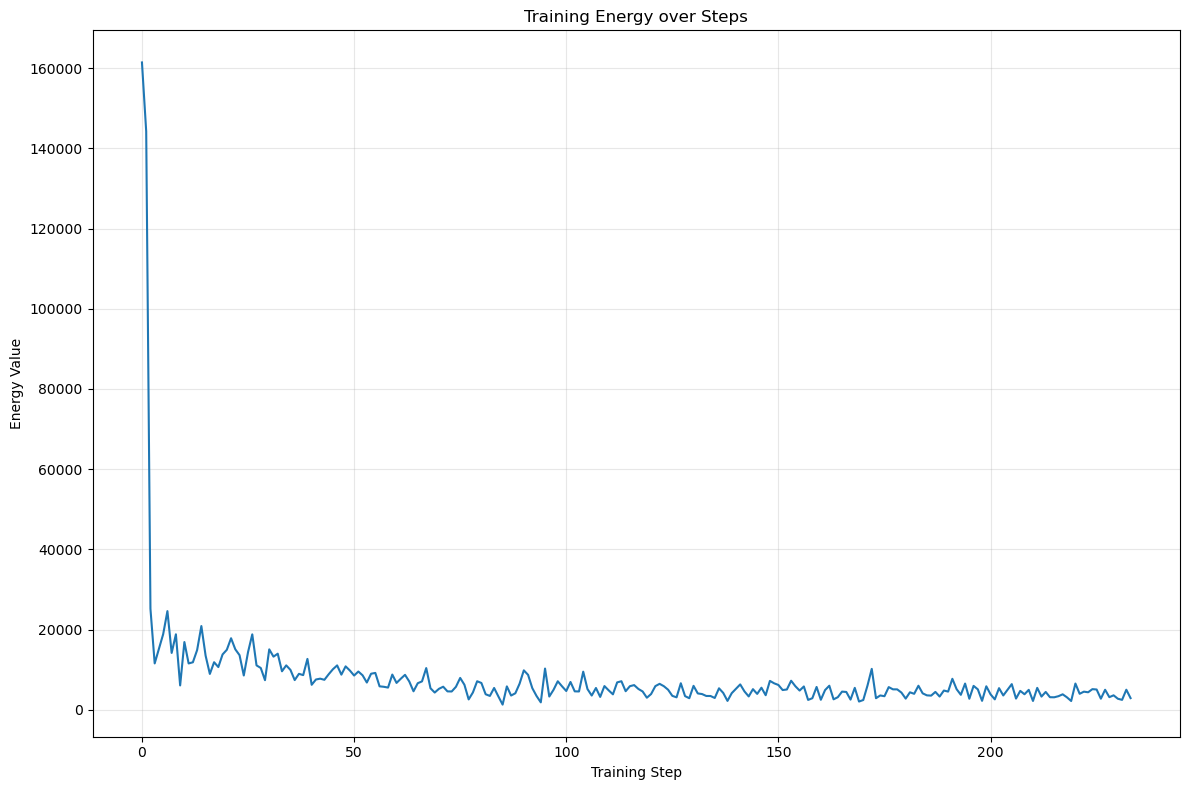

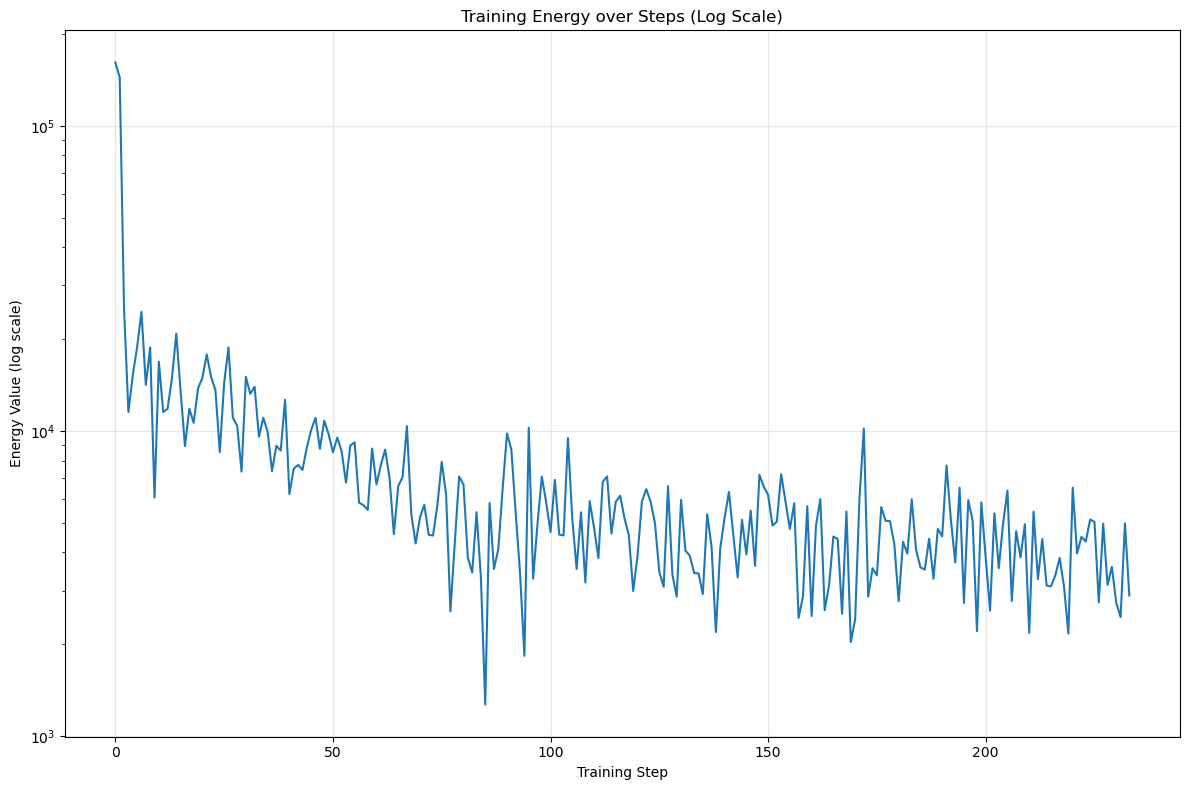


Metric Statistics:
Initial value: 1.614259e+05
Final value: 2.890909e+03
Minimum value: 1.268600e+03
Maximum value: 1.614259e+05
Total training steps: 233


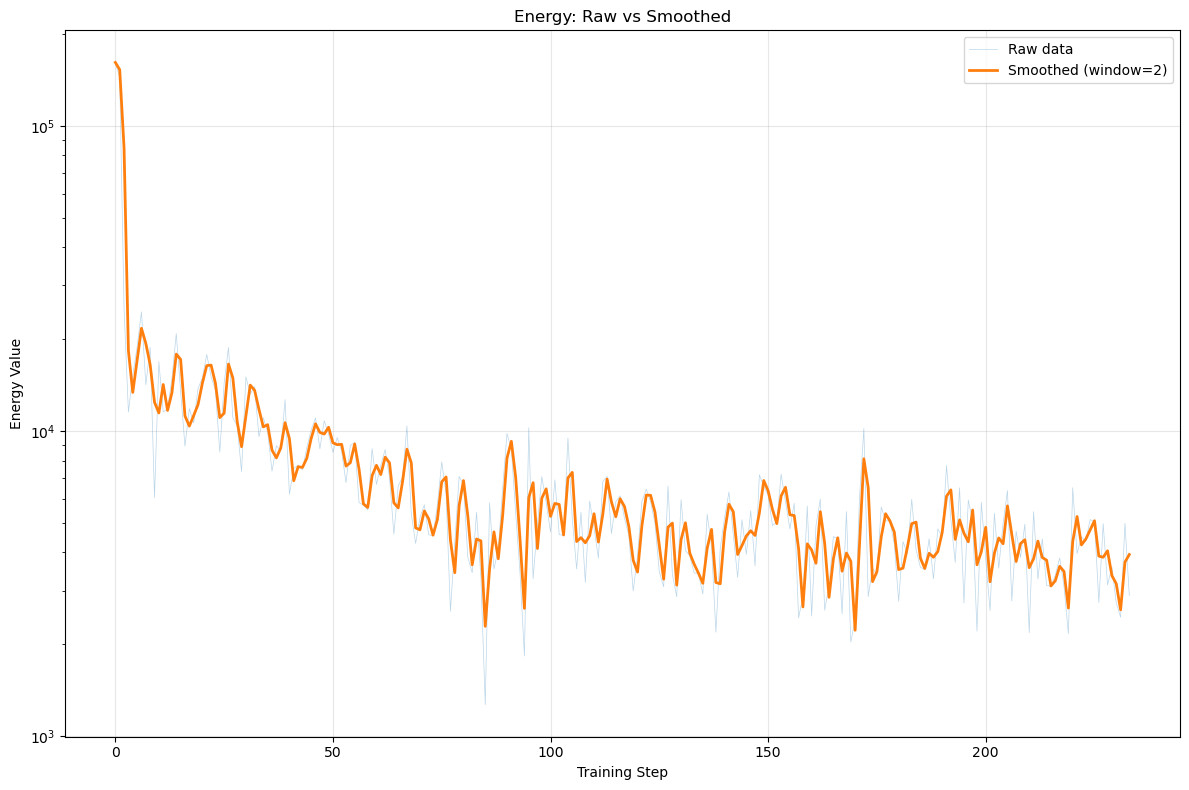

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Input: CSV file name (downloaded from TensorBoard)
csv_file = "~/Downloads/tensorboard.csv"

# Load the CSV file
df = pd.read_csv(csv_file)

# Display basic info
print("Columns in CSV:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head())

# Convert to numpy arrays to avoid pandas/matplotlib compatibility issues
steps = df['Step'].values
values = df['Value'].values

# Plot the metric over training steps
plt.figure(figsize=(12, 8))
plt.plot(steps, values, linewidth=1.5)
plt.xlabel('Training Step')
plt.ylabel('Energy Value')
plt.title('Training Energy over Steps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# If you know this is loss data, you might want to use log scale
plt.figure(figsize=(12, 8))
plt.semilogy(steps, values, linewidth=1.5)
plt.xlabel('Training Step')
plt.ylabel('Energy Value (log scale)')
plt.title('Training Energy over Steps (Log Scale)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some statistics
print(f"\nMetric Statistics:")
print(f"Initial value: {values[0]:.6e}")
print(f"Final value: {values[-1]:.6e}")
print(f"Minimum value: {np.min(values):.6e}")
print(f"Maximum value: {np.max(values):.6e}")
print(f"Total training steps: {steps[-1]}")

# Additional analysis: smoothed trend
from scipy.ndimage import uniform_filter1d

# Apply smoothing to see the trend better
window_size = max(1, len(values) // 100)  # Smooth over 1% of data points
smoothed_values = uniform_filter1d(values, size=window_size)

plt.figure(figsize=(12, 8))
plt.semilogy(steps, values, alpha=0.3, linewidth=0.5, label='Raw data')
plt.semilogy(steps, smoothed_values, linewidth=2, label=f'Smoothed (window={window_size})')
plt.xlabel('Training Step')
plt.ylabel('Energy Value')
plt.title('Energy: Raw vs Smoothed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()